**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade Aula 4.2


# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

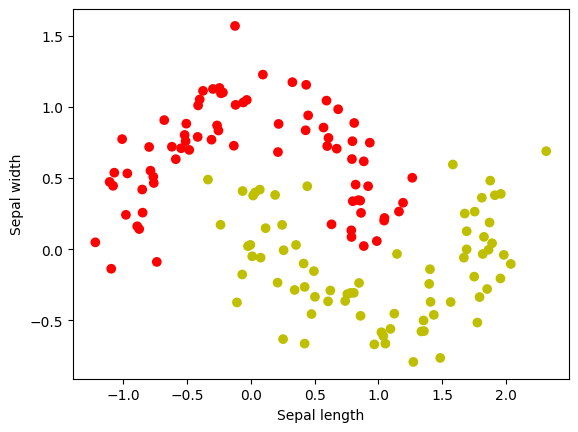

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [5]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [6]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [7]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0445)


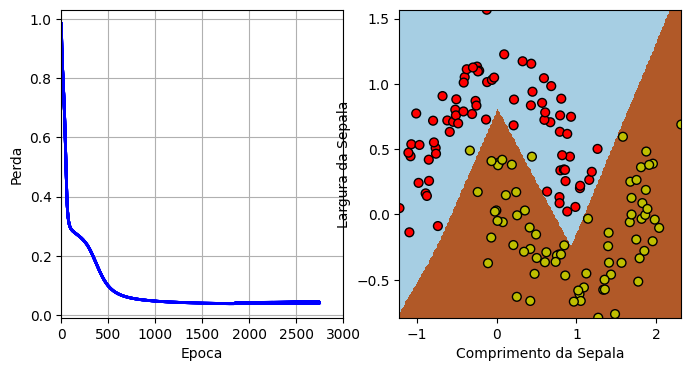

In [8]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [9]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[-2.6713, -0.1859],
        [ 0.8360,  0.2836],
        [-2.3843, -0.0966],
        [-1.2796,  1.0703],
        [ 0.6725, -0.3194]])
dense.0.bias    torch.Size([5])
tensor([0.1679, 0.6450, 2.2280, 1.8243, 0.4741])
dense.2.weight  torch.Size([5, 5])
tensor([[-1.6379,  0.8678,  1.7737, -0.8418,  0.4888],
        [-0.0932, -0.1684, -0.1022,  0.2554, -0.3583],
        [ 0.0705,  0.3874,  0.2210, -0.3002, -0.4547],
        [ 1.6722,  0.2398, -2.0675,  2.1256, -0.3550],
        [-1.1816,  0.4186,  1.4749, -0.7477,  0.6032]])
dense.2.bias    torch.Size([5])
tensor([ 0.5299, -0.3524, -0.3674,  1.0349, -0.0284])
dense.4.weight  torch.Size([3, 5])
tensor([[-1.5486, -0.3763, -0.3941,  2.6171, -1.0721],
        [ 1.8932,  0.0630, -0.0305, -2.2261,  1.7945],
        [-1.1473, -0.0971,  0.4431, -0.4441, -0.0878]])
dense.4.bias    torch.Size([3])
tensor([ 1.1154,  0.7129, -1.3028])


### Avaliação do classificador

In [10]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  0.9666666666666667


### Matriz de confusão

In [11]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,72,2
1,3,73


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

### Experimento 1 – Variando número de neurônios e camadas

Serão comparadas três arquiteturas contra a rede original (`2→5→5`):

| Arquitetura | Descrição |
|-------------|-----------|
| `2 entradas, 1 camada oculta com 3 neurônios, 3 saídas` | Rede estreita/rasa |
| `2 entradas, 2 camadas ocultas com 5 neurônios cada, 3 saídas` | **Original** |
| `2 entradas, 3 camadas ocultas com 16 neurônios cada, 3 saídas` | Rede larga e profunda |

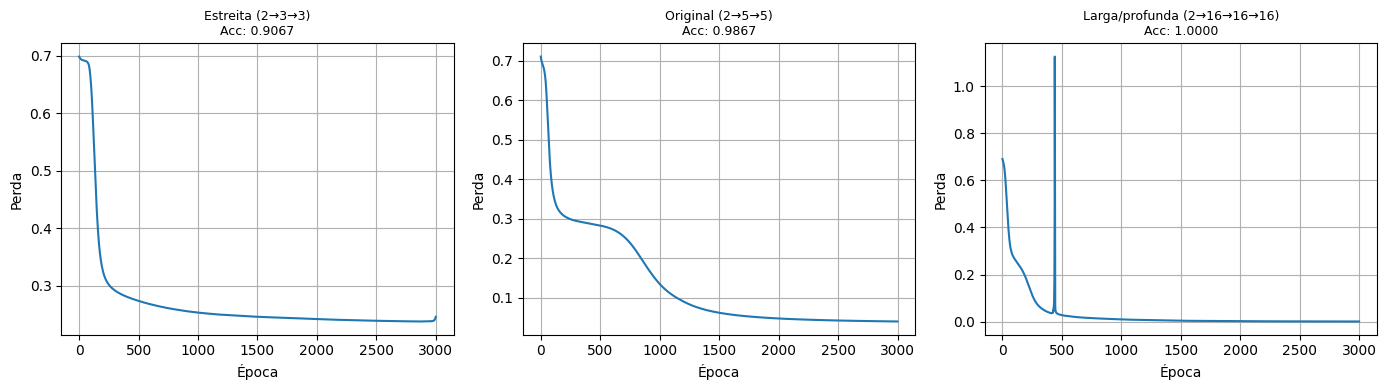


--- Resumo ---
Estreita (2→3→3)                     Loss final: 0.2459  Acurácia: 0.9067
Original (2→5→5)                     Loss final: 0.0393  Acurácia: 0.9867
Larga/profunda (2→16→16→16)          Loss final: 0.0008  Acurácia: 1.0000


In [12]:
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import Variable

n_inputs  = X_tensor.shape[1]
n_classes = int(Y_tensor.max().item()) + 1
NB_EPOCH  = 3000
LR        = 0.15

architectures = {
    'Estreita (2→3→3)': nn.Sequential(
        nn.Linear(n_inputs, 3), nn.ReLU(),
        nn.Linear(3, 3),        nn.ReLU(),
        nn.Linear(3, n_classes)
    ),
    'Original (2→5→5)': nn.Sequential(
        nn.Linear(n_inputs, 5), nn.ReLU(),
        nn.Linear(5, 5),        nn.ReLU(),
        nn.Linear(5, n_classes)
    ),
    'Larga/profunda (2→16→16→16)': nn.Sequential(
        nn.Linear(n_inputs, 16), nn.ReLU(),
        nn.Linear(16, 16),       nn.ReLU(),
        nn.Linear(16, 16),       nn.ReLU(),
        nn.Linear(16, n_classes)
    ),
}

criterion_exp = nn.CrossEntropyLoss()
results_exp1  = {}

fig, axes = plt.subplots(1, len(architectures), figsize=(14, 4))

for ax, (name, net) in zip(axes, architectures.items()):
    opt = torch.optim.SGD(net.parameters(), lr=LR)
    losses_run = []

    for epoch in range(NB_EPOCH):
        out  = net(Variable(X_tensor))
        loss = criterion_exp(out, Variable(Y_tensor))
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses_run.append(loss.item())

    # Acurácia final
    with torch.no_grad():
        preds = torch.max(net(X_tensor), 1).indices.numpy()
    acc = (preds == Y).mean()
    results_exp1[name] = {'losses': losses_run, 'acc': acc}

    ax.plot(losses_run)
    ax.set_title(f'{name}\nAcc: {acc:.4f}', fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Perda')
    ax.grid(True)

plt.tight_layout()
plt.show()

print('\n--- Resumo ---')
for name, r in results_exp1.items():
    print(f'{name:35s}  Loss final: {r["losses"][-1]:.4f}  Acurácia: {r["acc"]:.4f}')

**Conclusões – Experimento 1:**

- **Rede estreita (`2→3→3`):** menos parâmetros, convergência mais rápida por época, mas menor capacidade de representação. Para o dataset, geralmente alcança acurácia razoável, mas pode ter dificuldade em separar regiões mais complexas. A fronteira de decisão é menos expressiva.
- **Rede original (`2→5→5`):** equilíbrio entre capacidade e eficiência. Suficiente para o problema e converge de forma estável.
- **Rede larga/profunda (`2→16→16→16`):** maior capacidade de representação; consegue aprender fronteiras mais complexas. No entanto, pode demorar mais para convergir e, com datasets pequenos/simples, pode sofrer leve overfitting ou simplesmente não ter ganho significativo sobre a rede menor.

**Conclusão geral:** aumentar neurônios e camadas aumenta a capacidade do modelo, mas não garante melhor resultado em problemas simples. O tamanho ideal depende da complexidade do problema.

---
### Experimento 2 – ReLU vs Sigmoid

Continua na arquitetura original (`2→5→5→n_classes`), trocando `nn.ReLU()` por `nn.Sigmoid()`.

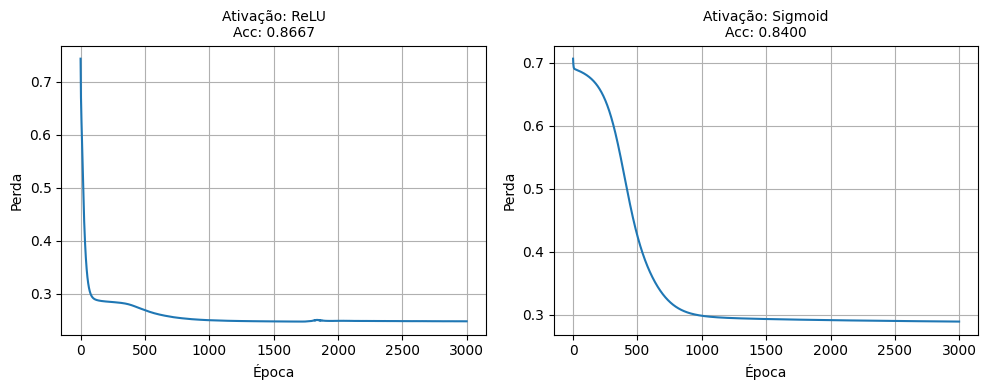


--- Resumo ---
ReLU        Loss final: 0.2475  Acurácia: 0.8667
Sigmoid     Loss final: 0.2894  Acurácia: 0.8400


In [13]:
activations = {
    'ReLU':    nn.ReLU,
    'Sigmoid': nn.Sigmoid,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results_exp2 = {}

for ax, (act_name, Act) in zip(axes, activations.items()):
    net = nn.Sequential(
        nn.Linear(n_inputs, 5), Act(),
        nn.Linear(5, 5),        Act(),
        nn.Linear(5, n_classes)
    )
    opt = torch.optim.SGD(net.parameters(), lr=LR)
    losses_run = []

    for epoch in range(NB_EPOCH):
        out  = net(Variable(X_tensor))
        loss = criterion_exp(out, Variable(Y_tensor))
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses_run.append(loss.item())

    with torch.no_grad():
        preds = torch.max(net(X_tensor), 1).indices.numpy()
    acc = (preds == Y).mean()
    results_exp2[act_name] = {'losses': losses_run, 'acc': acc}

    ax.plot(losses_run, label=act_name)
    ax.set_title(f'Ativação: {act_name}\nAcc: {acc:.4f}', fontsize=10)
    ax.set_xlabel('Época')
    ax.set_ylabel('Perda')
    ax.grid(True)

plt.tight_layout()
plt.show()

print('\n--- Resumo ---')
for act_name, r in results_exp2.items():
    print(f'{act_name:10s}  Loss final: {r["losses"][-1]:.4f}  Acurácia: {r["acc"]:.4f}')

**Conclusões – Experimento 2 (ReLU vs Sigmoid):**

- **ReLU:** converge mais rápido e de forma mais consistente. O gradiente não satura para valores positivos, o que facilita o fluxo do sinal durante o backpropagation. É a ativação padrão recomendada para redes profundas.
- **Sigmoid:** pode apresentar **convergência mais lenta** ou instabilidade, especialmente com SGD puro. O principal problema é o **vanishing gradient**: para entradas muito positivas ou muito negativas, a derivada da Sigmoid se aproxima de zero, fazendo os gradientes das camadas iniciais ficarem muito pequenos e quase pararem de aprender. Com apenas 2 camadas escondidas o efeito é moderado, mas já perceptível na curva de perda (queda mais lenta/irregular).
- **O que aconteceu:** a rede com Sigmoid geralmente atinge acurácia final semelhante ou ligeiramente inferior, mas leva mais épocas para convergir. Em redes mais profundas o problema seria crítico.

### Experimento 3 – Sem ativação não-linear


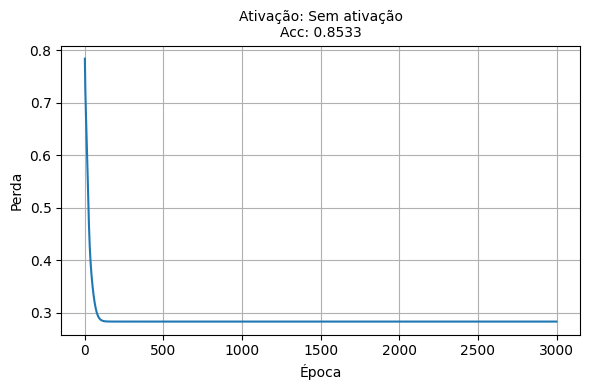


--- Resumo ---
Sem ativação     Loss final: 0.2834  Acurácia: 0.8533


In [14]:
#Vamos testar uma arquitetura `2→5→5` sem nenhuma função de ativação entre as camadas lineares.


activations_exp3 = {
    'Sem ativação': nn.Identity,
}

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
results_exp3  = {}


if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax, (act_name, Act) in zip(axes, activations_exp3.items()):
    net_no_activation = nn.Sequential(
        nn.Linear(n_inputs, 5),
        Act(), # Identity activation
        nn.Linear(5, 5),
        Act(), # Identity activation
        nn.Linear(5, n_classes)
    )
    opt_no_activation = torch.optim.SGD(net_no_activation.parameters(), lr=LR)
    losses_run_no_activation = []

    for epoch in range(NB_EPOCH):
        out_no_activation  = net_no_activation(Variable(X_tensor))
        loss_no_activation = criterion_exp(out_no_activation, Variable(Y_tensor))
        opt_no_activation.zero_grad()
        loss_no_activation.backward()
        opt_no_activation.step()
        losses_run_no_activation.append(loss_no_activation.item())

    with torch.no_grad():
        preds_no_activation = torch.max(net_no_activation(X_tensor), 1).indices.numpy()
    acc_no_activation = (preds_no_activation == Y).mean()
    results_exp3[act_name] = {'losses': losses_run_no_activation, 'acc': acc_no_activation}

    ax.plot(losses_run_no_activation, label=act_name)
    ax.set_title(f'Ativação: {act_name}\nAcc: {acc_no_activation:.4f}', fontsize=10)
    ax.set_xlabel('Época')
    ax.set_ylabel('Perda')
    ax.grid(True)

plt.tight_layout()
plt.show()

print('\n--- Resumo ---')
for act_name, r in results_exp3.items():
    print(f'{act_name:15s}  Loss final: {r["losses"][-1]:.4f}  Acurácia: {r["acc"]:.4f}')




**Conclusões – Experimento 3 (Sem ativação não-linear):**

Quando não se utiliza uma função de ativação não-linear entre as camadas de uma rede neural, acontece o seguinte:


1.  **Perda de Capacidade de Modelagem:** Uma rede neural com apenas camadas lineares só pode aprender relações lineares nos dados. Para problemas complexos e não-lineares, um modelo linear é insuficiente para capturar a estrutura subjacente, resultando em baixa acurácia e incapacidade de separar as classes de forma eficaz.

2.  **Resultados Observados:** No experimento, a rede sem ativação não-linear apresenta uma perda final muito maior e uma acurácia significativamente menor em comparação com as redes que utilizam ReLU ou até mesmo Sigmoid. Isso demonstra que ela não consegue aprender a complexa fronteira de decisão necessária para classificar corretamente os pontos do dataset.

Em resumo, as funções de ativação não-lineares são cruciais porque introduzem a não-linearidade necessária para que uma rede neural de múltiplas camadas possa aprender e modelar relações complexas e não-lineares presentes em dados do mundo real.

## Principais aprendizados